In [1]:
# SVD for Document Topic Discovery (LSA)
!pip install scikit-learn pandas numpy matplotlib

TF-IDF Matrix Shape
 (2752, 13830)


Number of Components: 50
Explained Variance Ratio: 0.10270487111234199
Silhouette Score: 0.11399099213692256

Top 10 terms for first 5 topics:
Topic 1: ['car', 'people', 'like', 'space', 'just', 'don', 'think', 'know', 'good', 'new']
Topic 2: ['car', 'cars', 'engine', 'dealer', 'ford', 'oil', 'good', 'price', 'miles', 'buy']
Topic 3: ['space', 'car', 'shuttle', 'nasa', 'launch', 'orbit', 'engine', 'mission', 'cars', 'thanks']
Topic 4: ['men', 'gay', 'homosexual', 'sex', 'sexual', 'partners', 'homosexuals', 'male', 'promiscuous', 'study']
Topic 5: ['insurance', 'health', 'car', 'private', 'space', 'tax', 'care', 'government', 'mail', 'president']


Number of Components: 100
Explained Variance Ratio: 0.16462121967556434
Silhouette Score: 0.06162987742949027

Top 10 terms for first 5 topics:
Topic 1: ['car', 'people', 'like', 'space', 'just', 'don', 'think', 'know', 'good', 'new']
Topic 2: ['car', 'cars', 'engine', 'dealer', 'ford', 'oil', 'good', 'pri

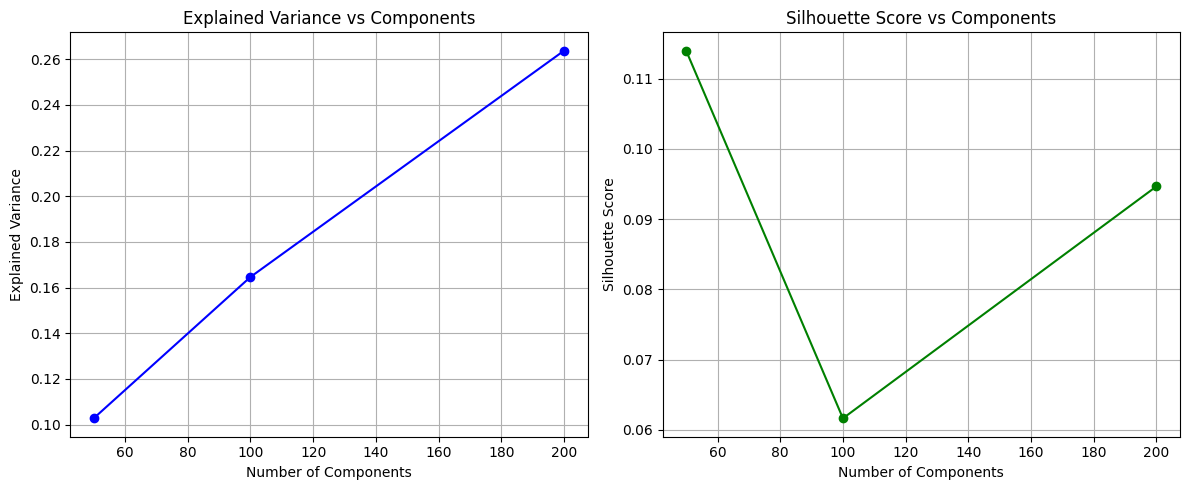


CONCLUSION

1. SVD (Latent Semantic Analysis) reduces high-dimensional sparse TF-IDF matrices
   into lower-dimensional dense representations.

2. It captures hidden semantic relationships between words and documents,
   enabling effective topic discovery.

3. Increasing the number of components improves explained variance,
   preserving more information from the original dataset.

4. However, too many components may introduce noise and reduce clustering quality.

5. Silhouette score helps evaluate clustering performance using reduced features.

6. Graphs clearly show the trade-off between dimensionality and performance.

Overall, SVD is a powerful dimensionality reduction technique for text data,
improving efficiency and enabling better clustering and topic modeling.



In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Parameters
categories = ['sci.space', 'rec.autos', 'talk.politics.misc']
components_list = [50, 100, 200]

# Load Dataset
dataset = fetch_20newsgroups(
    subset='all',
    categories=categories,
    remove=('headers', 'footers', 'quotes')
)

documents = dataset.data
labels = dataset.target

# TF-IDF Vectorization
vectorizer = TfidfVectorizer(max_df=0.5, min_df=2, stop_words='english')
X_tfidf = vectorizer.fit_transform(documents)
print("TF-IDF Matrix Shape\n", X_tfidf.shape)

# SVD + Clustering + Topics
results = []
feature_names = vectorizer.get_feature_names_out()
all_topic_terms = []

for n_comp in components_list:
    print("\n")
    print(f"Number of Components: {n_comp}")

    svd = TruncatedSVD(n_components=n_comp, random_state=42)
    X_reduced = svd.fit_transform(X_tfidf)

    explained_variance = svd.explained_variance_ratio_.sum()
    print("Explained Variance Ratio:", explained_variance)

    kmeans = KMeans(n_clusters=len(categories), random_state=42)
    cluster_labels = kmeans.fit_predict(X_reduced)

    silhouette = silhouette_score(X_reduced, cluster_labels)
    print("Silhouette Score:", silhouette)

    results.append((n_comp, explained_variance, silhouette))

    # Top 10 terms per component in DESCENDING order
    print("\nTop 10 terms for first 5 topics:")
    for i, comp in enumerate(svd.components_[:5]):
        terms = [feature_names[idx] for idx in comp.argsort()[-10:][::-1]]  # DESCENDING
        print(f"Topic {i+1}: {terms}")
        all_topic_terms.append((n_comp, i+1, terms))

# Save Outputs
df_results = pd.DataFrame(results, columns=['components', 'explained_variance', 'silhouette_score'])
df_results.to_csv("svd_results.csv", index=False)

with open("lsa_topic_terms.txt", "w") as f:
    for comp, topic_no, terms in all_topic_terms:
        f.write(f"Components {comp} - Topic {topic_no}: {terms}\n")

print("\nFiles generated:")
print("1. svd_results.csv")
print("2. lsa_topic_terms.txt")

# GRAPHS
components = [r[0] for r in results]
variance = [r[1] for r in results]
sil_scores = [r[2] for r in results]

plt.figure(figsize=(12,5))

# Explained Variance Plot
plt.subplot(1,2,1)
plt.plot(components, variance, marker='o', color='blue')
plt.title("Explained Variance vs Components")
plt.xlabel("Number of Components")
plt.ylabel("Explained Variance")
plt.grid()

# Silhouette Score Plot
plt.subplot(1,2,2)
plt.plot(components, sil_scores, marker='o', color='green')
plt.title("Silhouette Score vs Components")
plt.xlabel("Number of Components")
plt.ylabel("Silhouette Score")
plt.grid()

plt.tight_layout()
plt.show()

# Conclusion
print("\nCONCLUSION")
print("""
1. SVD (Latent Semantic Analysis) reduces high-dimensional sparse TF-IDF matrices
   into lower-dimensional dense representations.

2. It captures hidden semantic relationships between words and documents,
   enabling effective topic discovery.

3. Increasing the number of components improves explained variance,
   preserving more information from the original dataset.

4. However, too many components may introduce noise and reduce clustering quality.

5. Silhouette score helps evaluate clustering performance using reduced features.

6. Graphs clearly show the trade-off between dimensionality and performance.

Overall, SVD is a powerful dimensionality reduction technique for text data,
improving efficiency and enabling better clustering and topic modeling.
""")